roBERTa scores at the thread level

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df_M_convo = pd.read_csv("M/data_sentiment/Doom_convo_final_filt.csv")
df_T_convo = pd.read_csv("T/Data/destiny2_convo_final_filt.csv")
df_E_convo = pd.read_csv("E_10+/Data/PvZGardenWarfare_convo_final_filt.csv")

df_M_convo = pd.concat([df_M_convo, pd.read_csv("M/data_sentiment/blackops3_convo_final.csv")], axis=0, ignore_index=True)
df_T_convo = pd.concat([df_T_convo, pd.read_csv("T/Data/StarWarsBattlefront_convo_final.csv")], axis=0, ignore_index=True)
df_E_convo = pd.concat([df_E_convo, pd.read_csv("E_10+/Data/splatoon_convo_final.csv")], axis=0, ignore_index=True)

list_of_corpora = [df_M_convo, df_T_convo, df_E_convo]


In [ ]:
for df in list_of_corpora:
    df = df.rename(columns={"sentiment_label": "roBERTa_sentiment_label"})

    df = df.rename(columns={"compound": "roBERTa_Compound"})


In [21]:
VADER_map = {
    "positive": "Positive",
    "negative": "Negative",
    "neutral": "Neutral"
}

label_map = {
    -1: "Negative",
    0: "Neutral",
    1: "Positive"
}

for df in list_of_corpora:
    df["VADER_sentiment_label"] = df["VADER_sentiment_label"].map(VADER_map)

    df["bert_label"] = df["bert_numeric"].map(label_map)

In [ ]:
import csv

df_M_convo.to_csv("combined_convo_sent_M.csv", index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_ALL)
df_T_convo.to_csv("combined_convo_sent_T.csv", index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_ALL)
df_E_convo.to_csv("combined_convo_sent_E.csv", index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_ALL)

In [ ]:
df_M_convo.head()

,Unnamed: 0,conversation_id,text,neg,neu,pos,compound,VADER_sentiment_label,bert_label,bert_score,bert_numeric
0,0.0,1dor2g,"Ok, so what I'm trying to do is combine all of...",0.128,0.720,0.152,0.8996,Positive,Neutral,0.564591,0
1,3.0,1dwf9y,I just went through most of Map08: Traps and T...,0.103,0.710,0.188,0.9919,Positive,Neutral,0.467390,0
2,6.0,1ec6p9,My birthday is in 2 days. My sister-in-law sai...,0.093,0.702,0.205,0.9870,Positive,Positive,0.664382,1
3,7.0,1ei55r,If you guys remember ([This](http://www.reddit...,0.065,0.801,0.134,0.9237,Positive,Neutral,0.393784,0
4,17.0,4ct5ee,"Hi guys, I deleted off my steam account the Do...",0.061,0.939,0.000,-0.4696,Negative,Negative,0.584811,-1


## convo - Summary Stats - roBERTa

In [ ]:
print("\n=== Dataset Overview ===")
print("\nShape:", df_M_convo.shape)

print("\n=== Sentiment Label Distribution ===")
roBERTa_counts_M = df_M_convo["bert_label"].value_counts()
roBERTa_percent_M = df_M_convo["bert_label"].value_counts(normalize=True) * 100

print("\nRaw roBERTa Counts: \n", roBERTa_counts_M)
print("\nPercentage:\n", roBERTa_percent_M)


=== Dataset Overview ===

Shape: (25000, 11)

=== Sentiment Label Distribution ===

Raw roBERTa Counts: 
 bert_label
Negative    9439
Neutral     9249
Positive    6312
Name: count, dtype: int64

Percentage:
 bert_label
Negative    37.756
Neutral     36.996
Positive    25.248
Name: proportion, dtype: float64


In [ ]:
print("\n   Dataset Overview    ")
print("\nShape:", df_T_convo.shape)

print("\n Sentiment Label Distribution    ")
roBERTa_counts_T = df_T_convo["bert_label"].value_counts()
roBERTa_percent_T = df_T_convo["bert_label"].value_counts(normalize=True) * 100

print("\nRaw roBERTa Counts: \n", roBERTa_counts_T)
print("\nPercentage:\n", roBERTa_percent_T)


=== Dataset Overview ===

Shape: (25000, 11)

=== Sentiment Label Distribution ===

Raw roBERTa Counts: 
 bert_label
Neutral     9912
Negative    9319
Positive    5769
Name: count, dtype: int64

Percentage:
 bert_label
Neutral     39.648
Negative    37.276
Positive    23.076
Name: proportion, dtype: float64


In [ ]:
print("\n=== Dataset Overview ===")
print("\nShape:", df_E_convo.shape)

print("\n=== Sentiment Label Distribution ===")
roBERTa_counts_E = df_E_convo["bert_label"].value_counts()
roBERTa_percent_E = df_E_convo["bert_label"].value_counts(normalize=True) * 100

print("\nRaw roBERTa Counts: \n", roBERTa_counts_E)
print("\nPercentage:\n", roBERTa_percent_E)


=== Dataset Overview ===

Shape: (25002, 11)

=== Sentiment Label Distribution ===

Raw roBERTa Counts: 
 bert_label
Neutral     10019
Negative     7800
Positive     7179
Name: count, dtype: int64

Percentage:
 bert_label
Neutral     40.079206
Negative    31.202496
Positive    28.718297
Name: proportion, dtype: float64


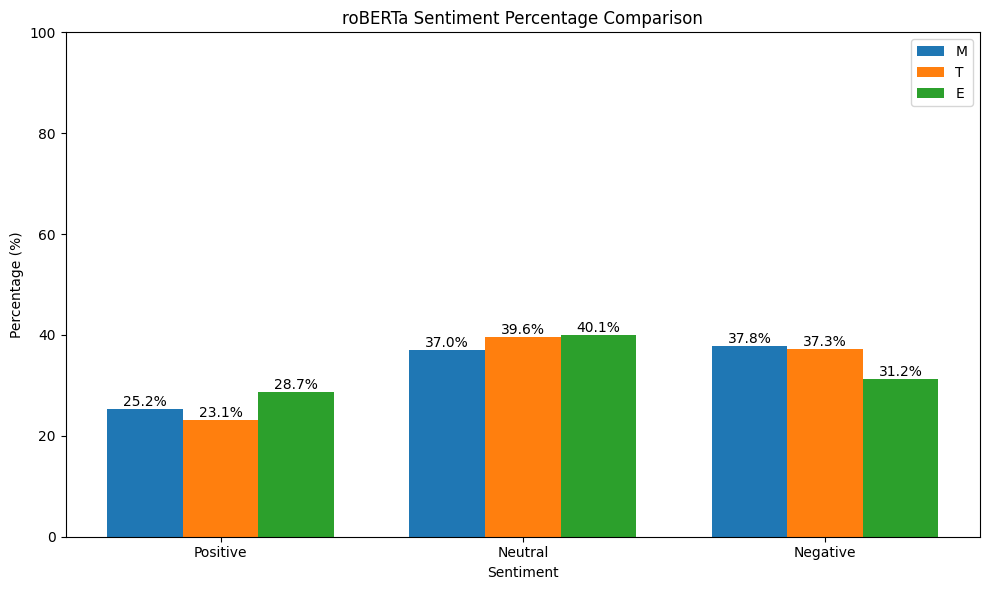

In [ ]:
labels = ['Positive', 'Neutral', 'Negative']
x = np.arange(len(labels))
width = 0.25

percent1 = roBERTa_percent_M.reindex(labels)
percent2 = roBERTa_percent_T.reindex(labels)
percent3 = roBERTa_percent_E.reindex(labels)

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - width, percent1.values, width, label="M")
bars2 = plt.bar(x, percent2.values, width, label="T")
bars3 = plt.bar(x + width, percent3.values, width, label="E")

for i in range(len(labels)):
    plt.text(x[i] - width, percent1.values[i], f"{percent1.values[i]:.1f}%", ha='center', va='bottom')
    plt.text(x[i], percent2.values[i], f"{percent2.values[i]:.1f}%", ha='center', va='bottom')
    plt.text(x[i] + width, percent3.values[i], f"{percent3.values[i]:.1f}%", ha='center', va='bottom')

plt.xticks(x, labels)

plt.title(f"roBERTa Sentiment Percentage Comparison")
plt.xlabel("Sentiment")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()